### 1. Load the Dataset and Select Features

In [1]:
import pandas as pd

# Load the Iris dataset
# Assuming 'iris.csv' is in the current directory or has a full path provided
try:
    df = pd.read_csv('iris.csv')
except FileNotFoundError:
    print("iris.csv not found. Please ensure the file is in the correct directory.")
    # Example to create a dummy dataframe if file not found for demonstration
    data = {'sepal_length': [5.1, 4.9, 4.7, 4.6, 5.0, 5.4, 4.6, 5.0, 4.4, 4.9],
            'sepal_width': [3.5, 3.0, 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1],
            'petal_length': [1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5],
            'petal_width': [0.2, 0.2, 0.2, 0.2, 0.2, 0.4, 0.3, 0.2, 0.2, 0.1],
            'species': ['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa']}
    df = pd.DataFrame(data)
    print("Created a dummy DataFrame for demonstration. Please upload 'iris.csv' if you want to use the actual data.")

# Select 'petal_width' and 'petal_length' features
X = df[['petal_length', 'petal_width']]

display(X.head())

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### 2. Preprocessing: Scaling Features

K-Means is a distance-based algorithm, meaning that features with larger values can have a disproportionately larger impact on the distance calculation. Therefore, scaling the features to have a similar range or distribution is often crucial for better performance.

Here, we will use `StandardScaler` to transform the data such that its distribution will have a mean value of 0 and a standard deviation of 1. This is a common practice before applying K-Means.

In [2]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())

,petal_length,petal_width
0,-1.341272,-1.312977
1,-1.341272,-1.312977
2,-1.398138,-1.312977
3,-1.284407,-1.312977
4,-1.341272,-1.312977


### 3. Determine Optimal K using the Elbow Method

The Elbow Method is a heuristic used in determining the number of clusters in a dataset. The idea is to run K-Means clustering for a range of 'k' values (number of clusters) and for each 'k', calculate the Within-Cluster Sum of Squares (WCSS). WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster.

We then plot the WCSS values against the number of clusters. The 'elbow' point on the graph, where the rate of decrease in WCSS sharply changes, is often considered a good indication of the optimal 'k'.

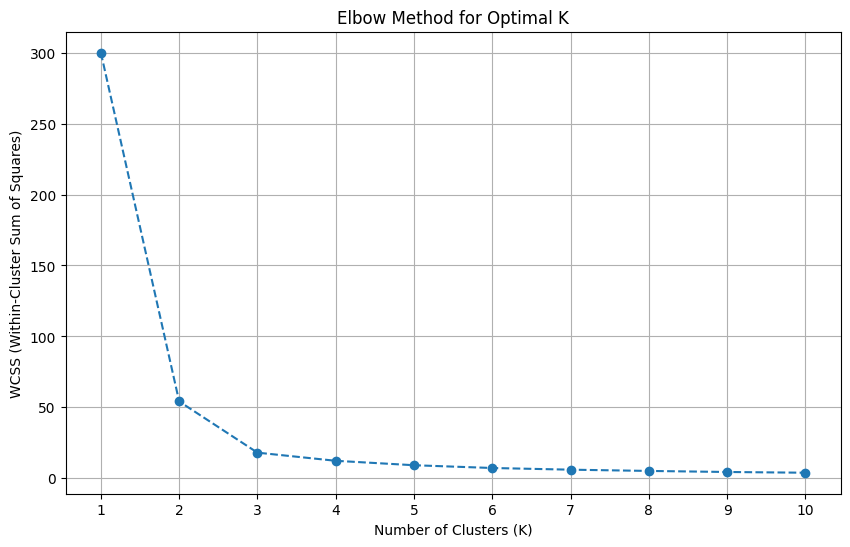

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
# Consider a range of k values, for example, from 1 to 10
# It's important to set a random_state for reproducibility
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS value

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

From the elbow plot, observe where the decrease in WCSS begins to slow down significantly, forming an 'elbow'. This point suggests a good trade-off between minimizing WCSS and having a reasonable number of clusters. Typically, for the Iris dataset, the optimal 'k' is often found to be 2 or 3.